# NHANES: self-report vs treatment vs measured biomarker — overview

Compares the three views of each chronic condition that NHANES provides — what people **say** about their diagnosis (Questionnaire files), what they **take** for it (medication items), and what their **body** shows (Exam/Lab files) — for every risk where two or more views exist. For the conditions where NHANES has only the self-report, we tabulate age/sex/time-specific prevalence so the gap left by the missing biomarker is at least visible.

## What's in here

1. `01_data_download.ipynb` — pulls 12 NHANES files × 3 cycles (2013–2018) for the cascade, plus DEMO + MCQ for the long 1999–2018 trend, plus the 2017–March 2020 pre-pandemic release for liver stiffness. Writes three analytic parquets to `../data/derived/`.
2. `02_comparison.ipynb` — for each of seven conditions, prevalence of self-report vs treatment vs elevated biomarker, plus the awareness/treatment/control cascade where applicable. Includes self-report vs measured BMI agreement and a cotinine-vs-SMQ smoking misclassification crosstab.
3. `03_age_sex_time_rates.ipynb` — for the three cardiovascular conditions with no NHANES biomarker (heart failure, AMI, stroke), prevalence by age × sex × four-year cycle bin, 1999–2018, with paired-PSU jackknife 95 % CIs.

## Conditions covered, by data availability

| Condition | Self-report | Treatment | Biomarker | Where in this project |
| --- | :-: | :-: | :-: | --- |
| Hypertension | `BPQ020` | `BPQ050A` | SBP (BPX) | 02, cascade |
| High cholesterol | `BPQ080` | `BPQ100D` | TC (TCHOL), LDL (TRIGLY) | 02, cascade |
| Diabetes | `DIQ010` | `DIQ050`/`DIQ070` | FPG (GLU) | 02, cascade |
| BMI | `WHD010`+`WHD020` | — | BMXBMI (BMX) | 02, agreement |
| Kidney dysfunction | `KIQ022` | `KIQ025` (dialysis) | eGFR ← `LBXSCR` (BIOPRO) | 02, cascade (aware only) |
| Liver fibrosis | `MCQ160L` | — | LSM (LUX) | 02, cascade (aware only) |
| Smoking | `SMQ020`+`SMQ040` | — | Cotinine (COT) | 02, crosstab |
| Lp(a) | — | — | LBDLPP (Lp(a) file, NHANES III only) | — (no self-report exists) |
| Heart failure | `MCQ160B` | — | — | 03, age/sex/time |
| AMI | `MCQ160E` | — | — | 03, age/sex/time |
| Stroke | `MCQ160F` | — | — | 03, age/sex/time |
| Revascularization | — | — | — | not in NHANES |

## Headline results

Below are the cascade and trend tables loaded from the executed notebooks.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DERIVED = Path(os.path.abspath(os.path.join('..', 'data'))) / 'derived'
comp = pd.read_parquet(DERIVED / 'sr_comparison_2013_2018.parquet')
lsm  = pd.read_parquet(DERIVED / 'sr_lsm_p2017_2020.parquet')
trend = pd.read_parquet(DERIVED / 'sr_trend_1999_2018.parquet')

def w_prop(v, w):
    m = ~np.isnan(v) & (w > 0)
    return float(np.average(v[m], weights=w[m])) if m.sum() else np.nan

def paired_jk(sub, var, wt='weight'):
    sub = sub.dropna(subset=[var, wt, 'SDMVPSU', 'SDMVSTRA'])
    sub = sub[sub[wt] > 0]
    if len(sub) < 30:
        return np.nan, np.nan
    v = sub[var].values.astype(float)
    w = sub[wt].values.astype(float)
    s = sub['SDMVSTRA'].astype(int).values
    p = sub['SDMVPSU'].astype(int).values
    theta = w_prop(v, w); var_sum = 0.0
    for st in np.unique(s):
        in_st = (s == st); psus = np.unique(p[in_st])
        if len(psus) < 2: continue
        for pu in psus:
            wr = w.copy()
            wr[in_st & (p == pu)] = 0.0
            wr[in_st & (p != pu)] *= 2.0
            th = w_prop(v, wr)
            if th == th: var_sum += (th - theta) ** 2
    return theta, np.sqrt(var_sum)

def cascade_row(name, df, denom_mask, aware_var, trt_var=None, ctrl_var=None,
                ctrl_mask=None, wt='weight'):
    sub = df[denom_mask].copy()
    a, ase = paired_jk(sub, aware_var, wt=wt)
    out = {'condition': name,
           'aware_pct': 100*a, 'aware_lo': 100*(a-1.96*ase), 'aware_hi': 100*(a+1.96*ase)}
    if trt_var:
        t, _ = paired_jk(sub, trt_var, wt=wt); out['treated_pct'] = 100*t
    if ctrl_var:
        c, _ = paired_jk(df[ctrl_mask].copy(), ctrl_var, wt=wt); out['ctrl_pct'] = 100*c
    return out

# Hypertension
d = comp.copy()
d['SBP_HIGH'] = (d['SBP_MEAN'] >= 140).astype(float); d.loc[d['SBP_MEAN'].isna(), 'SBP_HIGH'] = np.nan
d['HBP_TRT_IMP'] = d['HBP_TRT'].fillna(0).where(~d['HBP_SELF'].isna(), np.nan)
d['HBP_ANY'] = ((d['SBP_HIGH'] == 1) | (d['HBP_TRT_IMP'] == 1)).astype(float)
d.loc[d['SBP_HIGH'].isna() & d['HBP_TRT_IMP'].isna(), 'HBP_ANY'] = np.nan
d['HBP_CTRL'] = (d['SBP_MEAN'] < 140).astype(float); d.loc[d['SBP_MEAN'].isna(), 'HBP_CTRL'] = np.nan
r_hbp = cascade_row('Hypertension', d, d['HBP_ANY'] == 1,
                    'HBP_SELF', 'HBP_TRT_IMP', 'HBP_CTRL', d['HBP_TRT_IMP'] == 1)

# High cholesterol
d = comp.copy()
d['TC_HIGH'] = (d['LBXTC'] >= 240).astype(float); d.loc[d['LBXTC'].isna(), 'TC_HIGH'] = np.nan
d['HC_TRT_IMP'] = d['HC_TRT'].fillna(0).where(~d['HC_SELF'].isna(), np.nan)
d['HC_ANY'] = ((d['TC_HIGH'] == 1) | (d['HC_TRT_IMP'] == 1)).astype(float)
d.loc[d['TC_HIGH'].isna() & d['HC_TRT_IMP'].isna(), 'HC_ANY'] = np.nan
d['HC_CTRL'] = (d['LBXTC'] < 240).astype(float); d.loc[d['LBXTC'].isna(), 'HC_CTRL'] = np.nan
r_hc = cascade_row('High cholesterol', d, d['HC_ANY'] == 1,
                   'HC_SELF', 'HC_TRT_IMP', 'HC_CTRL', d['HC_TRT_IMP'] == 1)

# Diabetes
d = comp.copy()
d['FPG_HIGH'] = (d['LBXGLU'] >= 126).astype(float); d.loc[d['LBXGLU'].isna(), 'FPG_HIGH'] = np.nan
d['DM_ANY'] = ((d['FPG_HIGH'] == 1) | (d['DM_SELF'] == 1)).astype(float)
d.loc[d['FPG_HIGH'].isna() & d['DM_SELF'].isna(), 'DM_ANY'] = np.nan
d['DM_CTRL'] = (d['LBXGLU'] < 126).astype(float); d.loc[d['LBXGLU'].isna(), 'DM_CTRL'] = np.nan
r_dm = cascade_row('Diabetes', d, d['DM_ANY'] == 1,
                   'DM_SELF', 'DM_TRT', 'DM_CTRL', d['DM_TRT'] == 1, wt='weight_fasting')

# Kidney
d = comp.copy()
d['CKD'] = (d['eGFR'] < 60).astype(float); d.loc[d['eGFR'].isna(), 'CKD'] = np.nan
r_kid = cascade_row('Kidney (eGFR<60)', d, d['CKD'] == 1, 'KID_SELF')

# Liver
d = lsm[lsm['LSM_VALID'] == True].copy()
d['LSM_HIGH'] = (d['LUXSMED'] >= 8).astype(float); d.loc[d['LUXSMED'].isna(), 'LSM_HIGH'] = np.nan
r_lsm = cascade_row('Liver (LSM≥8)', d, d['LSM_HIGH'] == 1, 'LIVER_SELF')

cascade = pd.DataFrame([r_hbp, r_hc, r_dm, r_kid, r_lsm]).round(1)

# Overall time trend
TIME_BINS = {'1999–2002': ['1999-2000', '2001-2002'],
             '2003–2006': ['2003-2004', '2005-2006'],
             '2007–2010': ['2007-2008', '2009-2010'],
             '2011–2014': ['2011-2012', '2013-2014'],
             '2015–2018': ['2015-2016', '2017-2018']}
TIME_MID = {k: int(k.split('–')[0]) + 1.5 for k in TIME_BINS}
rows = []
for var, name in [('STROKE_SELF', 'Stroke'),
                  ('AMI_SELF',    'AMI'),
                  ('HF_SELF',     'Heart failure')]:
    for tb, cycles in TIME_BINS.items():
        sub = trend[trend['CYCLE'].isin(cycles)]
        theta, se = paired_jk(sub.copy(), var)
        rows.append({'condition': name, 'mid': TIME_MID[tb],
                     'pct': 100*theta, 'lo': 100*(theta-1.96*se),
                     'hi': 100*(theta+1.96*se)})
overall = pd.DataFrame(rows)

### Awareness/treatment/control cascade, NHANES 2013–2018

Denominator for each row = adults ≥20 meeting the "elevated" definition (biomarker above cutoff OR currently on treatment). Treatment uses the convention that those who said "no" to the screening question are coded as untreated.

In [2]:
display = cascade.copy()
display['Aware (95% CI)'] = display.apply(
    lambda r: f"{r['aware_pct']:.1f} ({r['aware_lo']:.1f}–{r['aware_hi']:.1f})", axis=1)
display['Treated'] = display['treated_pct'].apply(
    lambda v: f"{v:.1f}" if pd.notna(v) else '—')
display['Controlled'] = display['ctrl_pct'].apply(
    lambda v: f"{v:.1f}" if pd.notna(v) else '—')
print(display[['condition', 'Aware (95% CI)', 'Treated', 'Controlled']].to_string(index=False))

       condition   Aware (95% CI) Treated Controlled
    Hypertension 84.2 (81.8–86.5)    76.2       69.5
High cholesterol 74.8 (72.1–77.5)    65.5       92.6
        Diabetes 77.5 (72.9–82.2)    68.8       28.4
Kidney (eGFR<60) 22.8 (18.5–27.2)       —          —
   Liver (LSM≥8)  11.8 (6.9–16.7)       —          —


**Reading the cascade.** Hypertension and high cholesterol have the most coherent cascade — high awareness (75-84 %), high treatment uptake among the aware, and high control of TC but only middling control of SBP. Diabetes shows the classic NHANES finding: roughly four-fifths know, two-thirds are treated, but only 28 % achieve FPG < 126 mg/dL (the harder bar). The under-diagnosed conditions are kidney dysfunction (eGFR < 60 → only 23 % self-report a kidney problem) and liver fibrosis (LSM ≥ 8 kPa → only 12 % self-report any liver condition); these are the two channels where self-report alone would dramatically understate prevalence.

### Self-report cardiovascular prevalence, 1999–2018

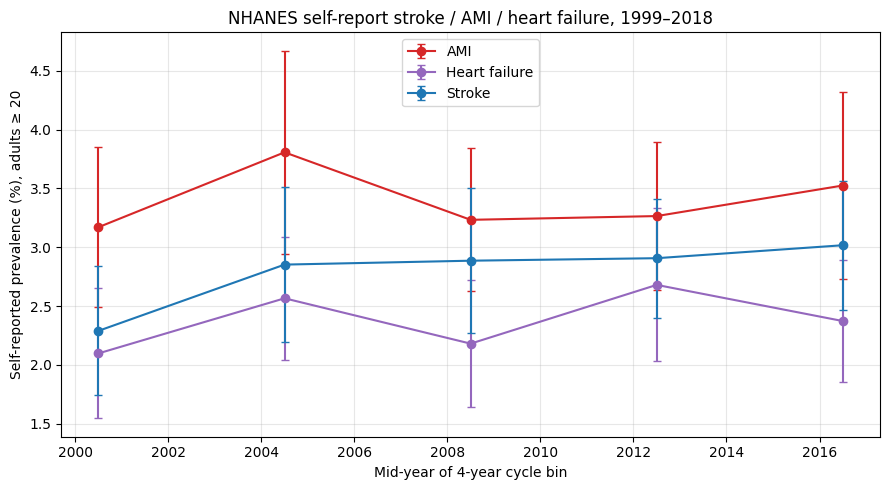

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = {'Stroke': 'tab:blue', 'AMI': 'tab:red', 'Heart failure': 'tab:purple'}
for name, sub in overall.groupby('condition'):
    sub = sub.sort_values('mid')
    yerr = [sub['pct'] - sub['lo'], sub['hi'] - sub['pct']]
    ax.errorbar(sub['mid'], sub['pct'], yerr=yerr, fmt='o-',
                capsize=3, color=colors[name], label=name)
ax.set_xlabel('Mid-year of 4-year cycle bin')
ax.set_ylabel('Self-reported prevalence (%), adults ≥ 20')
ax.set_title('NHANES self-report stroke / AMI / heart failure, 1999–2018')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

All three sit between 2 % and 4 % overall and are roughly flat over two decades — small upward drift in stroke, no clear movement in AMI or HF. The interesting variation is age × sex (see notebook 03): AMI is roughly twice as common in men as women at every age, while heart failure converges across sexes after age 70.

## Methods notes

- All proportions are weighted by `WTMEC2YR` (or its pre-pandemic combined equivalent `WTMECPRP`). For the pooled cascade, weights are divided by the number of cycles per NCHS analytic guidelines.
- Variance is estimated by paired-PSU jackknife on `SDMVPSU × SDMVSTRA`; CIs are `point ± 1.96 × SE`.
- eGFR uses the CKD-EPI 2021 race-free equation.
- Liver stiffness uses the FibroScan VCTE median (`LUXSMED`), with `LUXSIQR / LUXSMED ≤ 0.30` as the reliability filter (EASL clinical practice guideline).
- Cotinine cutoff of 10 ng/mL is the conventional active-smoker threshold used in NHANES tobacco-use reports.